
# Paso 2 — Ruteo navegable (corrige las líneas rectas que cruzan tierra)

En el paso 1 (`../01_tiempos_distancias/`) vimos que las líneas rectas (Haversine)
que tocan **Bryggen** cruzan tierra: Bryggen está metida en la bahía de Vågen, al
lado de la **península de Nordnes**, y una línea recta hacia Kleppestø, Laksevåg o
Sandviken pasa por encima de esa península o del centro de Bergen en vez de
bordearlos por agua.

**Qué hace este notebook:**
1. Descarga un mapa real de la zona y clasifica cada píxel como agua o tierra.
2. Construye una malla (grafo) de píxeles de agua, conectados a sus vecinos.
3. Calcula la ruta más corta **que no cruza tierra** entre cada par de nodos
   (Dijkstra sobre la malla) — esto reemplaza la línea recta por un camino real.
4. Recalibra la velocidad efectiva con la distancia navegable real del tramo
   Kleppestø–Bryggen (en vez de la distancia en línea recta).
5. Guarda la nueva matriz de tiempos — **esta es la que deben usar los pasos
   siguientes** (`03_demanda/` en adelante), no la de `01_tiempos_distancias/`.

Toda la lógica reutilizable vive en [`../src/water_routing.py`](../src/water_routing.py).


In [1]:

import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import geopandas as gpd
import contextily as cx
from shapely.geometry import Point, LineString

sys.path.insert(0, str(Path.cwd().parent / "src"))
import geo
import water_routing as wr

CONFIG_PATH = Path.cwd().parent / "config" / "instance.yaml"
OUTPUT_DIR = Path.cwd() / "output"
OUTPUT_DIR.mkdir(exist_ok=True)
OUTPUT_DIR_01 = Path.cwd().parent / "01_tiempos_distancias" / "output"

pd.set_option("display.width", 100)
plt.rcParams["figure.dpi"] = 110

COLOR_DEMANDA = "#1f6f8b"
COLOR_WAYPOINT = "#9a9a9a"
COLOR_RUTA_NAVEGABLE = "#1a8f5a"
COLOR_RECTA = "#c0392b"


## 1. Nodos y área de trabajo

Igual que en el paso 1: los 4 nodos de demanda + Hegreneset como waypoint de
referencia. Se define un cuadro (bbox) alrededor de todos ellos, con margen,
para descargar el mapa de esa zona.


In [2]:

cfg = geo.cargar_instancia(CONFIG_PATH)
nodos_demanda_df = geo.nodos_a_dataframe(cfg["nodos_demanda"])
waypoints_df = geo.nodos_a_dataframe(cfg.get("waypoints", []))
nodos_todos_df = pd.concat([nodos_demanda_df, waypoints_df])

PAD_LAT, PAD_LON = 0.012, 0.03
west = nodos_todos_df["lon"].min() - PAD_LON
east = nodos_todos_df["lon"].max() + PAD_LON
south = nodos_todos_df["lat"].min() - PAD_LAT
north = nodos_todos_df["lat"].max() + PAD_LAT

nodos_todos_df[["nombre", "lat", "lon"]]


,nombre,lat,lon
id,,,
kleppesto,Kleppestø (Askøy),60.406500,5.227500
laksevag,Laksevåg (Gravdal),60.390886,5.259586
bryggen,Bryggen / Sentrum,60.395100,5.322300
sandviken,Sandviken (BSI Padling),60.421149,5.300502
hegreneset,Hegreneset,60.418500,5.312500


## 2. Descargar el mapa y clasificar agua/tierra

Se usa CartoDB Positron **sin etiquetas** (`PositronNoLabels`): con etiquetas, el
texto de nombres de lugares se dibuja encima del agua y se clasificaría por error
como tierra.

### Cómo se construye la máscara, en detalle

1. **Se descarga un mosaico de tiles XYZ** (el mismo formato que usan Google Maps,
   OpenStreetMap, etc.) para el bbox de la instancia, a un nivel de **zoom fijo**
   (`ZOOM` abajo). En el estándar de tiles, cada nivel de zoom tiene una resolución
   **constante en todo el mundo**, medida en metros *proyectados* (Web Mercator,
   EPSG:3857): `metros_mercator_por_pixel = 156543.03392 / 2**zoom`.
2. Web Mercator **no** preserva distancias reales: a una latitud φ, un metro
   proyectado equivale a `cos(φ)` metros reales en el terreno (por eso Groenlandia
   se ve gigante en un mapamundi Mercator). Bergen está a ≈60.4°N, donde
   `cos(60.4°) ≈ 0.494` — así que la resolución real en el suelo es casi el doble
   de fina que la resolución proyectada. Con `ZOOM=14` eso da **≈4.7 metros por
   píxel** en Bergen (se calcula exacto más abajo). Es decir, cada "cuadrito" de
   la malla representa un cuadrado de ~4.7 × 4.7 m de agua o tierra real.
3. **Clasificación por color:** se descargó un tile de prueba de Bergen y se
   contaron los colores de píxel más frecuentes. El agua en CartoDB Positron
   resultó tener un color muy consistente, `COLOR_AGUA_POSITRON = (212, 218, 220)`
   (gris-azulado claro), que aparecía en ~40% de los píxeles del área de prueba —
   consistente con ser el color del fiordo. Cada píxel se clasifica como agua si
   su distancia euclidiana en espacio RGB a ese color de referencia es menor a un
   umbral (`umbral_color=15`); si no, es tierra.
4. **Por qué queda tan pegada a la costa real:** porque es *literalmente* el mismo
   raster que dibuja el mapa. La conversión píxel↔lon/lat usa la misma fórmula
   de Web Mercator esférico (mismo radio, 6378137 m) que usó el servidor de tiles
   para renderizar la imagen — así que al superponer la máscara clasificada de
   vuelta sobre el mapa original (ver la figura de abajo), coincide píxel a píxel
   por construcción. La precisión de la costa depende de qué tan buena sea la
   geometría de OpenStreetMap (que es la fuente de datos de CartoDB), no de nada
   que hayamos aproximado nosotros.

Todo esto vive en `wr.descargar_mascara_agua()` (paso 1-2) y las funciones
`wr.pixel_a_lonlat()` / `wr.lonlat_a_pixel()` (la conversión de coordenadas) en
[`../src/water_routing.py`](../src/water_routing.py).


In [3]:
t0 = time.time()
ZOOM = 14
water_mask, ext = wr.descargar_mascara_agua(west, south, east, north, zoom=ZOOM)

# Resolución real en el suelo (no la proyectada) a la latitud de Bergen:
lat_centro = nodos_todos_df["lat"].mean()
merc_m_por_px = 156543.03392 / (2 ** ZOOM)
suelo_m_por_px = merc_m_por_px * np.cos(np.radians(lat_centro))

print(f"Descargado en {time.time()-t0:.1f} s | tamaño malla: {water_mask.shape} "
      f"({water_mask.size:,} píxeles, {water_mask.mean()*100:.1f}% agua)")
print(f"Resolución: {merc_m_por_px:.2f} m/píxel (proyectada) -> {suelo_m_por_px:.2f} m/píxel (real, "
      f"a {lat_centro:.1f}°N, factor cos(lat)={np.cos(np.radians(lat_centro)):.3f})")


Descargado en 22.6 s | tamaño malla: (1536, 2048) (3,145,728 píxeles, 34.4% agua)
Resolución: 9.55 m/píxel (proyectada) -> 4.72 m/píxel (real, a 60.4°N, factor cos(lat)=0.494)


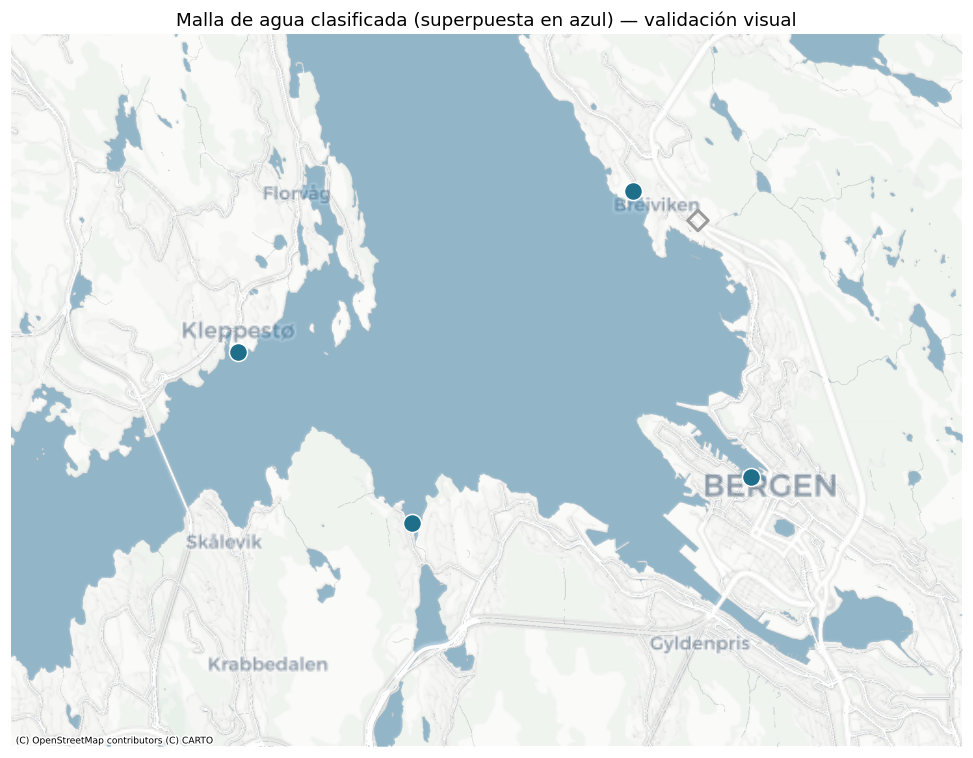

In [4]:

# Validación visual: la máscara clasificada (azul) superpuesta sobre el mapa real.
gdf_demanda = gpd.GeoDataFrame(
    nodos_demanda_df,
    geometry=[Point(lon, lat) for lat, lon in zip(nodos_demanda_df["lat"], nodos_demanda_df["lon"])],
    crs="EPSG:4326",
).to_crs(epsg=3857)
gdf_waypoints = gpd.GeoDataFrame(
    waypoints_df,
    geometry=[Point(lon, lat) for lat, lon in zip(waypoints_df["lat"], waypoints_df["lon"])],
    crs="EPSG:4326",
).to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 7))
xmin, xmax, ymin, ymax = ext
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, attribution_size=6, crs="EPSG:3857")

overlay = np.zeros((*water_mask.shape, 4))
overlay[water_mask] = [0.10, 0.45, 0.65, 0.35]  # azul semitransparente sobre el agua clasificada
ax.imshow(overlay, extent=(xmin, xmax, ymin, ymax), origin="upper", zorder=2)

gdf_demanda.plot(ax=ax, color=COLOR_DEMANDA, edgecolor="white", markersize=140, zorder=3)
gdf_waypoints.plot(ax=ax, color="none", edgecolor=COLOR_WAYPOINT, linewidth=2, marker="D", markersize=90, zorder=3)

ax.set_axis_off()
ax.set_title("Malla de agua clasificada (superpuesta en azul) — validación visual", fontsize=12)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "mapa_mascara_agua.png", dpi=200, bbox_inches="tight")
plt.show()


## 3. Construir el grafo navegable

Cada píxel de agua es un nodo de un grafo, conectado a sus **8 vecinos** (arriba,
abajo, izquierda, derecha y las 4 diagonales) *si esos vecinos también son agua*
— si un vecino es tierra, simplemente no existe esa arista, así que el grafo
nunca ofrece un salto que cruce tierra. El peso de cada arista es la distancia
real en km entre los centros de los dos píxeles (con la corrección `cos(lat)` de
la celda anterior aplicada fila por fila, no un valor único para todo el mapa).

Con ~4.7 m/píxel y un bbox de varios km, esto da un grafo de **~1 millón de
nodos** y **~8 millones de aristas dirigidas** — grande, pero como es disperso
(cada nodo solo toca a sus 8 vecinos) `scipy.sparse` lo maneja en menos de un
segundo.

**El espaciado de la malla es el tamaño del píxel, en metros reales — no hay una
distancia de grilla elegida aparte.** Un nodo del grafo *es* un píxel de agua, así
que el paso entre dos nodos vecinos es exactamente la resolución real calculada en
la sección 2 (~4.72 m ortogonal, ~6.67 m en diagonal, con ZOOM=14). Subir el ZOOM
da una malla más fina (más nodos, más precisión, más lento); bajarlo da una malla
más gruesa.


In [5]:
t0 = time.time()
grafo, node_ids, pixel_de_nodo = wr.construir_grafo_navegable(water_mask, ext)
print(f"Grafo construido en {time.time()-t0:.1f} s | {grafo.shape[0]:,} nodos, {grafo.nnz:,} aristas dirigidas")
print(f"Espaciado real de la malla (= la grilla es literalmente el pixel del mapa, no una distancia aparte):")
print(f"  paso ortogonal (vecino arriba/abajo/izq/der): ~{suelo_m_por_px:.2f} m")
print(f"  paso diagonal  (vecino en diagonal):            ~{suelo_m_por_px*2**0.5:.2f} m")


Grafo construido en 1.1 s | 1,081,855 nodos, 8,403,546 aristas dirigidas
Espaciado real de la malla (= la grilla es literalmente el pixel del mapa, no una distancia aparte):
  paso ortogonal (vecino arriba/abajo/izq/der): ~4.72 m
  paso diagonal  (vecino en diagonal):            ~6.67 m


## 4. Distancias navegables (Dijkstra)

### Cómo funciona Dijkstra aquí, en detalle

1. **Snap:** las coordenadas reales de cada puerto casi nunca caen justo en un
   píxel clasificado como agua (pueden caer un pixel adentro del muelle, p.ej.).
   `wr.snap_a_grafo()` busca el píxel de agua más cercano en espiral creciente,
   **restringido a la componente conexa principal** del grafo (calculada con
   `scipy.sparse.csgraph.connected_components`): esto evita enganchar un puerto
   a un charco o estanque aislado que el color clasificó como agua pero que no
   está conectado al mar abierto (nos pasó con Hegreneset en una primera versión).
2. **Dijkstra multi-fuente:** `scipy.sparse.csgraph.dijkstra(grafo, indices=[...],
   return_predecessors=True)` corre el algoritmo de Dijkstra una vez por cada
   nodo/puerto de origen (todos en la misma llamada). Como todos los pesos de las
   aristas son distancias reales (siempre positivas), Dijkstra garantiza encontrar
   el camino de **menor distancia total** desde cada origen hacia todos los demás
   ~1 millón de nodos del grafo — no hace falta A* ni ninguna heurística: con este
   tamaño de grafo, Dijkstra puro corre en ~1 segundo para las 5 fuentes.
3. **Resultado:** una matriz `dist_matrix[origen, destino]` con la distancia real
   navegada (no en línea recta) entre cualquier par de píxeles del grafo. Para la
   matriz de puertos, simplemente se consulta esa matriz en las posiciones (fila,
   columna) de los píxeles a los que se enganchó cada puerto.
4. **Reconstrucción de la ruta:** Dijkstra también devuelve `predecessors`, el
   nodo anterior en el camino más corto hacia cada destino. `wr.reconstruir_ruta_latlon()`
   camina esa cadena de predecesores hacia atrás (destino → origen), junta los
   píxeles visitados y los convierte de vuelta a lon/lat — así se dibuja la ruta
   real en los mapas de abajo, no solo se reporta un número de distancia.

Como solo hay aristas entre pares de píxeles de agua, es **estructuralmente
imposible** que el camino más corto encontrado por Dijkstra cruce tierra.


In [6]:

t0 = time.time()
dist_km_navegable, snap_idx, predecessors, ids_orden = wr.matriz_distancias_navegables(
    nodos_todos_df, water_mask, ext, grafo, node_ids
)
print(f"Listo en {time.time()-t0:.1f} s")
dist_km_navegable.loc[nodos_demanda_df.index, nodos_demanda_df.index].round(2)


Listo en 1.8 s


id,kleppesto,laksevag,bryggen,sandviken
id,,,,
kleppesto,0.00,2.67,5.75,4.78
laksevag,2.67,0.00,4.31,4.31
bryggen,5.75,4.31,0.00,3.41
sandviken,4.78,4.31,3.41,0.00


## 5. Velocidad de diseño fija

En vez de calibrar la velocidad con la distancia navegable del tramo
Kleppestø–Bryggen (como en una versión anterior de este notebook), el equipo
decidió usar una **velocidad de diseño fija para toda la flota: 30 km/h**
(`config/instance.yaml` -> `calibracion.velocidad_forzada_kmh`). No es la
velocidad de un ferry existente; es una suposición de diseño para los barcos
pequeños a demanda, que se puede volver a barrer más adelante.


In [7]:
cal = cfg["calibracion"]
velocidad_kmh = geo.calibrar_velocidad_kmh(
    nodos_demanda_df,
    desde=cal["referencia_desde"],
    hasta=cal["referencia_hasta"],
    tiempo_referencia_min=cal["tiempo_referencia_min"],
    velocidad_forzada_kmh=cal.get("velocidad_forzada_kmh"),
)
print(f"Velocidad de diseño usada: {velocidad_kmh:.2f} km/h ({velocidad_kmh/1.852:.1f} nudos)")

dist_navegable_referencia = dist_km_navegable.loc[cal["referencia_desde"], cal["referencia_hasta"]]
tiempo_a_30kmh = dist_navegable_referencia / velocidad_kmh * 60
print(f"Ej. Kleppestø-Bryggen: {dist_navegable_referencia:.2f} km navegables -> {tiempo_a_30kmh:.1f} min a {velocidad_kmh:.0f} km/h "
      f"(el dato real del ferry 490 es 14 min a su propia velocidad de crucero, no comparable 1 a 1 con esta flota nueva)")


Velocidad de diseño usada: 30.00 km/h (16.2 nudos)
Ej. Kleppestø-Bryggen: 5.75 km navegables -> 11.5 min a 30 km/h (el dato real del ferry 490 es 14 min a su propia velocidad de crucero, no comparable 1 a 1 con esta flota nueva)


## 6. Matriz de tiempos navegables

Con la velocidad de diseño (30 km/h), convertimos la matriz de distancias
navegables a minutos.


In [8]:
tiempos_min_navegable = dist_km_navegable / velocidad_kmh * 60.0
tiempos_min_navegable.loc[nodos_demanda_df.index, nodos_demanda_df.index].round(1)


id,kleppesto,laksevag,bryggen,sandviken
id,,,,
kleppesto,0.0,5.3,11.5,9.6
laksevag,5.3,0.0,8.6,8.6
bryggen,11.5,8.6,0.0,6.8
sandviken,9.6,8.6,6.8,0.0


## 7. Comparación: línea recta (paso 1) vs. navegable (este paso)

Diferencia porcentual por par de nodos. Como ambos lados usan la misma
velocidad fija (30 km/h), la diferencia porcentual en tiempo es idéntica a la
diferencia porcentual en distancia — se muestran ambas para que quede explícito.
Las conexiones que tocan Bryggen siguen siendo las que más cambian, como en el
paso 1.


In [9]:
dist_km_recta = geo.matriz_distancias(nodos_demanda_df)
tiempos_min_recta = geo.matriz_tiempos(dist_km_recta, velocidad_kmh)

filas = []
ids_demanda = nodos_demanda_df.index.tolist()
for i, a in enumerate(ids_demanda):
    for b in ids_demanda[i + 1:]:
        d_recta = dist_km_recta.loc[a, b]
        d_nav = dist_km_navegable.loc[a, b]
        filas.append({
            "par": f"{nodos_demanda_df.loc[a,'nombre']} <-> {nodos_demanda_df.loc[b,'nombre']}",
            "km_recta": round(d_recta, 2),
            "km_navegable": round(d_nav, 2),
            "diferencia_%": round((d_nav / d_recta - 1) * 100, 1),
            "min_recta": round(tiempos_min_recta.loc[a, b], 1),
            "min_navegable": round(tiempos_min_navegable.loc[a, b], 1),
        })

comparacion_df = pd.DataFrame(filas).sort_values("diferencia_%", ascending=False).reset_index(drop=True)
comparacion_df


,par,km_recta,km_navegable,diferencia_%,min_recta,min_navegable
0,Laksevåg (Gravdal) <-> Bryggen / Sentrum,3.48,4.31,23.8,7.0,8.6
1,Kleppestø (Askøy) <-> Sandviken (BSI Padling),4.33,4.78,10.5,8.7,9.6
2,Bryggen / Sentrum <-> Sandviken (BSI Padling),3.13,3.41,8.9,6.3,6.8
3,Kleppestø (Askøy) <-> Laksevåg (Gravdal),2.47,2.67,7.8,4.9,5.3
4,Kleppestø (Askøy) <-> Bryggen / Sentrum,5.36,5.75,7.3,10.7,11.5
5,Laksevåg (Gravdal) <-> Sandviken (BSI Padling),4.05,4.31,6.4,8.1,8.6


## 8. Guardar matrices

La matriz de tiempos navegables (`matriz_tiempos_min.csv` en este `output/`) es
la que deben usar los pasos siguientes en vez de la del paso 1.


In [10]:

dist_km_navegable.loc[ids_demanda, ids_demanda].to_csv(OUTPUT_DIR / "matriz_distancias_km.csv")
tiempos_min_navegable.loc[ids_demanda, ids_demanda].to_csv(OUTPUT_DIR / "matriz_tiempos_min.csv")
dist_km_navegable.to_csv(OUTPUT_DIR / "matriz_distancias_km_con_waypoints_REFERENCIA.csv")
tiempos_min_navegable.to_csv(OUTPUT_DIR / "matriz_tiempos_min_con_waypoints_REFERENCIA.csv")
comparacion_df.to_csv(OUTPUT_DIR / "comparacion_recta_vs_navegable.csv", index=False)

with open(OUTPUT_DIR / "velocidad_usada_kmh.txt", "w", encoding="utf-8") as f:
    f.write(f"{velocidad_kmh:.6f}\n")

print("Guardado en:", OUTPUT_DIR)
sorted(p.name for p in OUTPUT_DIR.iterdir())


Guardado en: C:\Users\hfons\Andes\OneDrive - Universidad de los Andes\NHH\NHH-Schedule-Free-Autonomous-Boats-in-Bergen\bergen-boats\02_ruteo_navegable\output


['comparacion_recta_vs_navegable.csv',
 'heatmap_tiempos_navegables.png',
 'mapa_mascara_agua.png',
 'mapa_rutas_navegables.png',
 'mapa_zoom_bryggen_comparacion.png',
 'matriz_distancias_km.csv',
 'matriz_distancias_km_con_waypoints_REFERENCIA.csv',
 'matriz_tiempos_min.csv',
 'matriz_tiempos_min_con_waypoints_REFERENCIA.csv',
 'velocidad_recalibrada_kmh.txt',
 'velocidad_usada_kmh.txt']

## 9. Mapa: las 6 rutas navegables reales

Cada línea ahora es el camino más corto que sí respeta la costa, no una recta.


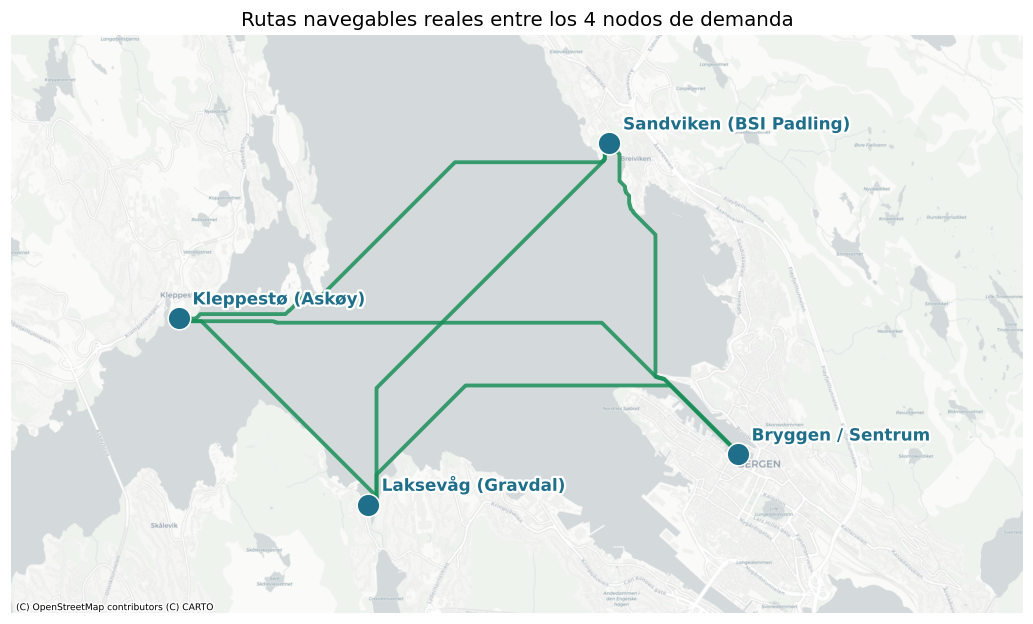

In [11]:

import itertools

rutas_geom = {}
for a, b in itertools.combinations(ids_demanda, 2):
    puntos = wr.reconstruir_ruta_latlon(a, b, ids_orden, snap_idx, predecessors, pixel_de_nodo, ext, water_mask.shape)
    linea_4326 = LineString([(lon, lat) for lat, lon in puntos])
    rutas_geom[(a, b)] = linea_4326

gdf_rutas = gpd.GeoDataFrame(
    [{"desde": a, "hasta": b, "distancia_km": dist_km_navegable.loc[a, b], "geometry": geom}
     for (a, b), geom in rutas_geom.items()],
    crs="EPSG:4326",
).to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(9.5, 9.5))
gdf_rutas.plot(ax=ax, color=COLOR_RUTA_NAVEGABLE, linewidth=2.5, alpha=0.85, zorder=2)
gdf_demanda.plot(ax=ax, color=COLOR_DEMANDA, edgecolor="white", markersize=220, zorder=3)

for nid, row in gdf_demanda.iterrows():
    ax.annotate(
        nodos_demanda_df.loc[nid, "nombre"], xy=(row.geometry.x, row.geometry.y),
        xytext=(9, 9), textcoords="offset points", fontsize=11, fontweight="bold",
        color=COLOR_DEMANDA, zorder=4, path_effects=[pe.withStroke(linewidth=3, foreground="white")],
    )

xmin_d, ymin_d, xmax_d, ymax_d = gdf_demanda.total_bounds
mx, my = (xmax_d - xmin_d) * 0.30, (ymax_d - ymin_d) * 0.30
ax.set_xlim(xmin_d - mx, xmax_d + mx * 1.7)
ax.set_ylim(ymin_d - my, ymax_d + my)

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, attribution_size=6, zoom=14)
ax.set_axis_off()
ax.set_title("Rutas navegables reales entre los 4 nodos de demanda", fontsize=13)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "mapa_rutas_navegables.png", dpi=200, bbox_inches="tight")
plt.show()


## 9b. Guardar las geometrías de las rutas navegables

Las 6 rutas de la sección anterior (`gdf_rutas`) solo se habían usado para dibujar
el mapa y luego se perdían. Se persisten aquí en `output/rutas_navegables.geojson`
(EPSG:4326, columnas `desde`, `hasta`, `distancia_km`, `geometry`) porque el paso
de simulación (siguiente, fuera de `bergen-boats/`) necesita la geometría real de
cada ruta para animar los barcos siguiendo la costa, no solo el tiempo de viaje.
No cambia ningún número ni conclusión de este notebook -- solo persiste algo que
ya se calculaba en memoria.


In [12]:
gdf_rutas_4326 = gdf_rutas.to_crs(epsg=4326)
gdf_rutas_4326.to_file(OUTPUT_DIR / "rutas_navegables.geojson", driver="GeoJSON")
print("Guardado:", OUTPUT_DIR / "rutas_navegables.geojson")
gdf_rutas_4326[["desde", "hasta", "distancia_km"]]


Guardado: C:\Users\hfons\Andes\OneDrive - Universidad de los Andes\NHH\NHH-Schedule-Free-Autonomous-Boats-in-Bergen\bergen-boats\02_ruteo_navegable\output\rutas_navegables.geojson


,desde,hasta,distancia_km
0,kleppesto,laksevag,2.665950
1,kleppesto,bryggen,5.751097
2,kleppesto,sandviken,4.781214
3,laksevag,bryggen,4.305751
4,laksevag,sandviken,4.305293
5,bryggen,sandviken,3.414436


## 10. Zoom sobre Bryggen: recta (paso 1) vs. ruta real (este paso)

La comparación directa que motivó este paso: en rojo punteado la línea recta
que cruzaba tierra, en verde sólido el camino real que bordea Nordnes.


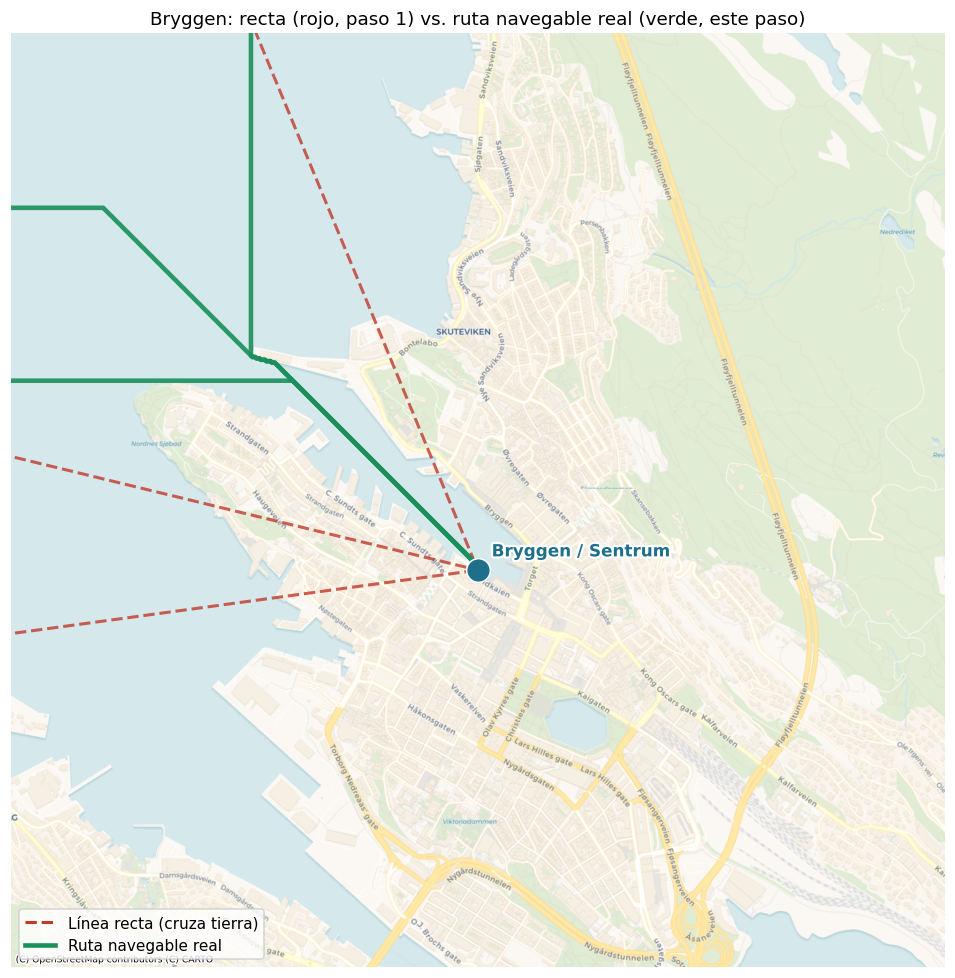

In [13]:

fig, ax = plt.subplots(figsize=(9, 9))

# rectas (para comparar) solo de los pares que tocan bryggen
for b in ["kleppesto", "laksevag", "sandviken"]:
    recta = LineString([gdf_demanda.loc["bryggen", "geometry"], gdf_demanda.loc[b, "geometry"]])
    gpd.GeoSeries([recta], crs="EPSG:3857").plot(ax=ax, color=COLOR_RECTA, linewidth=2, linestyle="--", alpha=0.8, zorder=2)

gdf_rutas_bryggen = gdf_rutas[(gdf_rutas["desde"] == "bryggen") | (gdf_rutas["hasta"] == "bryggen")]
gdf_rutas_bryggen.plot(ax=ax, color=COLOR_RUTA_NAVEGABLE, linewidth=3, alpha=0.9, zorder=3)

gdf_demanda.plot(ax=ax, color=COLOR_DEMANDA, edgecolor="white", markersize=240, zorder=4)
for nid, row in gdf_demanda.iterrows():
    ax.annotate(
        nodos_demanda_df.loc[nid, "nombre"], xy=(row.geometry.x, row.geometry.y),
        xytext=(9, 9), textcoords="offset points", fontsize=11, fontweight="bold",
        color=COLOR_DEMANDA, zorder=5, path_effects=[pe.withStroke(linewidth=3, foreground="white")],
    )

bx = gdf_demanda.loc["bryggen", "geometry"]
radio_m = 3200
ax.set_xlim(bx.x - radio_m, bx.x + radio_m)
ax.set_ylim(bx.y - radio_m * 0.85, bx.y + radio_m * 1.15)

cx.add_basemap(ax, source=cx.providers.CartoDB.Voyager, attribution_size=6, zoom=15)
ax.set_axis_off()
ax.set_title("Bryggen: recta (rojo, paso 1) vs. ruta navegable real (verde, este paso)", fontsize=12)

from matplotlib.lines import Line2D
leyenda = [
    Line2D([0], [0], color=COLOR_RECTA, linestyle="--", linewidth=2, label="Línea recta (cruza tierra)"),
    Line2D([0], [0], color=COLOR_RUTA_NAVEGABLE, linewidth=3, label="Ruta navegable real"),
]
ax.legend(handles=leyenda, loc="lower left", fontsize=10, frameon=True)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "mapa_zoom_bryggen_comparacion.png", dpi=200, bbox_inches="tight")
plt.show()


## 11. Heatmap de la matriz de tiempos navegables


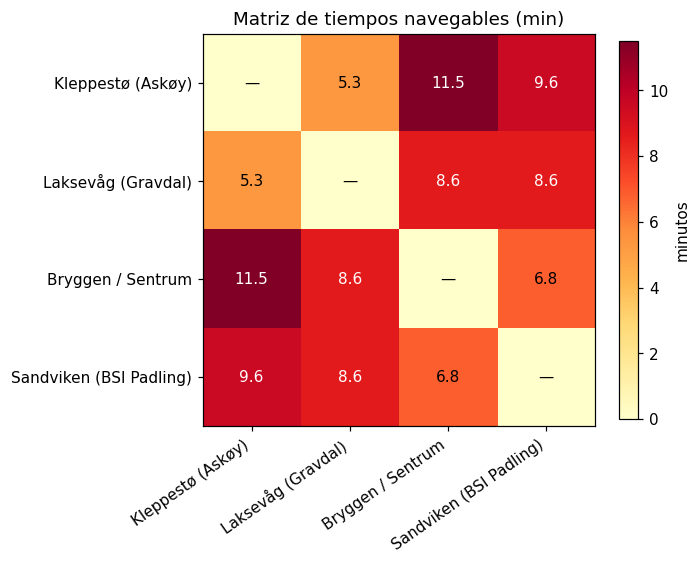

In [14]:

fig, ax = plt.subplots(figsize=(6.5, 5.5))
etiquetas = nodos_demanda_df["nombre"].tolist()
sub = tiempos_min_navegable.loc[ids_demanda, ids_demanda].values
im = ax.imshow(sub, cmap="YlOrRd", vmin=0)

ax.set_xticks(range(len(etiquetas))); ax.set_yticks(range(len(etiquetas)))
ax.set_xticklabels(etiquetas, rotation=35, ha="right"); ax.set_yticklabels(etiquetas)

for i in range(len(etiquetas)):
    for j in range(len(etiquetas)):
        valor = sub[i, j]
        texto = "—" if i == j else f"{valor:.1f}"
        color = "white" if valor > sub.max() * 0.6 else "black"
        ax.text(j, i, texto, ha="center", va="center", color=color, fontsize=10)

cbar = fig.colorbar(im, ax=ax, shrink=0.85); cbar.set_label("minutos")
ax.set_title("Matriz de tiempos navegables (min)")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "heatmap_tiempos_navegables.png", dpi=200, bbox_inches="tight")
plt.show()


## Resumen

- Se construyó un **módulo de ruteo sobre agua** (`../src/water_routing.py`, reutilizable
  en pasos futuros) que clasifica un mapa real en agua/tierra (a ~4.7 m/píxel en Bergen) y
  calcula caminos más cortos que no cruzan tierra (Dijkstra sobre una malla de píxeles).
- La velocidad usada es una **decisión de diseño fija** (`config/instance.yaml`), no una
  calibración contra un ferry real — ver sección 5.
- Las conexiones que tocan Bryggen (las 3 "garantías fuertes" del modelo) son las que
  más se alargan al pasar de línea recta a ruta navegable real — ver la tabla de la sección 7.
- **A partir de aquí, los pasos siguientes deben usar `output/matriz_tiempos_min.csv`
  de este notebook**, no el de `01_tiempos_distancias/`.
- **Siguiente paso:** `../03_demanda/` — generar las solicitudes Poisson por franja horaria.
